
# Week 2 — Baseline Prediction Models & Evaluation

In this notebook, you will build **baseline prediction models** for financial
returns and evaluate them using **strictly forward-looking (time-series)
validation**.

This week focuses on **evaluation discipline**, not on maximizing performance.


## 1. Imports

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

plt.style.use("seaborn-v0_8")



## 2. Load data from Week 1

- Reuse the data you created in Week 1.
- You can use one stock of your choice (you can repeat it for multiple stocks if you want and plot them separately)
- Take a long term horizon data set (5-10 years)


In [6]:
import yfinance as yf

plt.style.use("seaborn-v0_8")

ticker = "AAPL"

data = yf.download(ticker, start="2015-01-01", end="2024-01-01", auto_adjust=False)

# Use Adjusted Close if present, else Close
if "Adj Close" in data.columns:
    prices = data[["Adj Close"]].rename(columns={"Adj Close": "Close"})
else:
    prices = data[["Close"]]

# Clean missing values
prices = prices.ffill().dropna()

# Daily simple returns r_t
prices["return"] = prices["Close"].pct_change()
returns = prices["return"].dropna().to_frame(name="r_t")

returns.head()


[*********************100%***********************]  1 of 1 completed


,r_t
Date,
2015-01-05,-0.028172
2015-01-06,0.000095
2015-01-07,0.014022
2015-01-08,0.038423
2015-01-09,0.001072



## 3. Feature construction

Required features:
- $r_t$
- $r_{t-1}$
- 20-day rolling mean
- 20-day rolling volatility
- 5-day momentum


In [7]:
# TODO: construct features using only past data

df = returns.copy()

# Current return r_t (target)
df["r_t"] = df["r_t"]

# Lagged return r_{t-1}
df["r_t_1"] = df["r_t"].shift(1)

# 20‑day rolling mean of returns
df["roll_mean_20"] = df["r_t"].rolling(window=20, min_periods=20).mean()

# 20‑day rolling volatility (std of returns)
df["roll_vol_20"] = df["r_t"].rolling(window=20, min_periods=20).std()

# 5‑day momentum: price_t / price_{t-5} - 1
# requires original price series aligned with df
df["price"] = prices["Close"].reindex(df.index)
df["mom_5"] = df["price"] / df["price"].shift(5) - 1

# Drop rows that use future data or have NaNs from rolling/shift
df = df.dropna()

# Define features X and target y
feature_cols = ["r_t_1", "roll_mean_20", "roll_vol_20", "mom_5"]
X = df[feature_cols].values
y = df["r_t"].values

df.head()

,r_t,r_t_1,roll_mean_20,roll_vol_20,price,mom_5
Date,,,,,,
2015-02-02,0.012547,-0.014634,0.004358,0.023813,26.299286,0.048895
2015-02-03,0.000168,0.012547,0.005775,0.022587,26.303717,0.087136
2015-02-04,0.007670,0.000168,0.006153,0.022551,26.505453,0.036857
2015-02-05,0.007137,0.007670,0.005809,0.022477,26.694633,0.012728
2015-02-06,-0.008421,0.007137,0.003467,0.021310,26.469851,0.019114



## 4. Naive baselines


In [8]:
# TODO: zero predictor

# Predict 0 return for every observation
y_pred_zero = np.zeros_like(y)

# Keep in a dict for later comparison
baseline_preds = {"zero": y_pred_zero}


In [9]:
# TODO: rolling mean predictor

# Use the same 20‑day rolling mean as a prediction (already only uses past data)
y_pred_roll_mean = df["roll_mean_20"].values

baseline_preds["roll_mean_20"] = y_pred_roll_mean



## 5. Linear models (OLS & Ridge)
Suggested that you review basic linear regression theory as well (resources given in README).

In [10]:
# use LinearRegression from sklearn

from sklearn.linear_model import Ridge

ols = LinearRegression()
ridge = Ridge(alpha=1.0)

# These models will be trained inside the TimeSeriesSplit loop (section 7),
# so here we just define them.
models = {
    "OLS": ols,
    "Ridge": ridge,
}



## 6. Tree-based model (Random Forest) (optional)


In [ ]:

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    min_samples_leaf=50,
    random_state=42
)



## 7. Walk-forward evaluation

- Scikit reference for [TimeSeriesSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html).

In [11]:
# TODO: implement TimeSeriesSplit evaluation

tscv = TimeSeriesSplit(n_splits=5)

# To store predictions aligned with y
preds_all = {name: np.full_like(y, np.nan, dtype=float) for name in baseline_preds.keys()}

# Add model names
for name in models.keys():
    preds_all[name] = np.full_like(y, np.nan, dtype=float)

# Walk‑forward loop
for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train = y[train_idx]

    # Baselines: no fitting needed, just slice
    preds_all["zero"][test_idx] = baseline_preds["zero"][test_idx]
    preds_all["roll_mean_20"][test_idx] = baseline_preds["roll_mean_20"][test_idx]

    # Linear models
    for name, model in models.items():
        model.fit(X_train, y_train)
        preds_all[name][test_idx] = model.predict(X_test)

# Optional Random Forest (if you want to include it)
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    min_samples_leaf=50,
    random_state=42
)

preds_all["RandomForest"] = np.full_like(y, np.nan, dtype=float)

for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train = y[train_idx]

    rf.fit(X_train, y_train)
    preds_all["RandomForest"][test_idx] = rf.predict(X_test)



## 8. Prediction accuracy


In [12]:
# TODO: compute RMSE for all models and compare them

rmse = {}
for name, y_hat in preds_all.items():
    mask = ~np.isnan(y_hat)
    rmse[name] = np.sqrt(mean_squared_error(y[mask], y_hat[mask]))

rmse


{'zero': np.float64(0.018668585682834218),
 'roll_mean_20': np.float64(0.018059282325599908),
 'OLS': np.float64(0.016073399514697023),
 'Ridge': np.float64(0.017132235570219666),
 'RandomForest': np.float64(0.016821269513313898)}

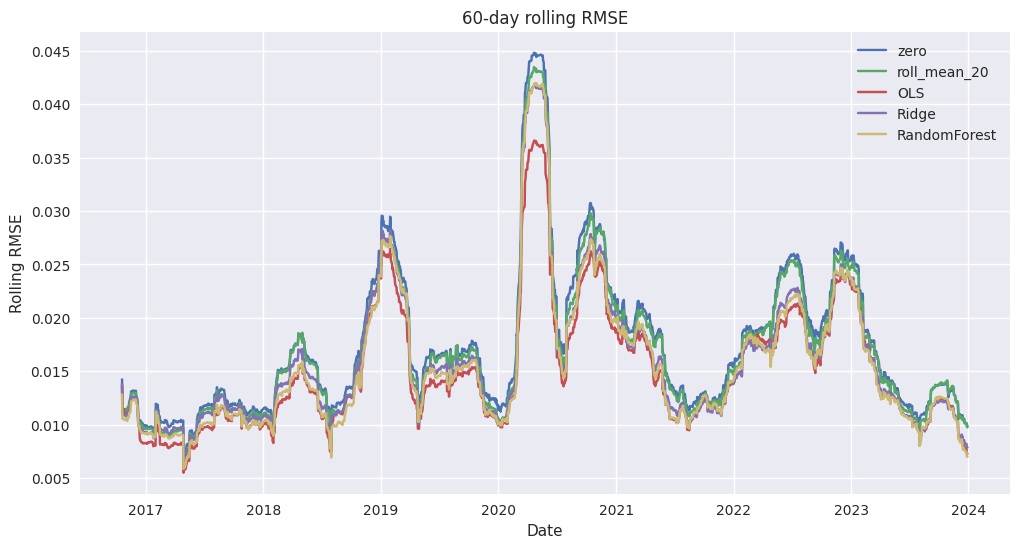

In [13]:
# TODO: plot rolling RMSE vs time for all models

window = 60  # 60 trading days ~ 3 months

rmse_roll = pd.DataFrame(index=df.index, columns=preds_all.keys(), dtype=float)

for name, y_hat in preds_all.items():
    err_sq = (y - y_hat) ** 2
    err_sq_series = pd.Series(err_sq, index=df.index)
    rmse_roll[name] = np.sqrt(err_sq_series.rolling(window=window, min_periods=window).mean())

plt.figure(figsize=(12, 6))
for name in rmse_roll.columns:
    plt.plot(rmse_roll.index, rmse_roll[name], label=name)

plt.ylabel("Rolling RMSE")
plt.xlabel("Date")
plt.title(f"{window}-day rolling RMSE")
plt.legend()
plt.show()


In [14]:
# Bonus: compute volatility scaled/normalized prediction error:
# sqrt( ((y_true - y_pred)**2) / (vol_t**2) ) - and compare across models

vol = df["roll_vol_20"].values
scaled_err = {}

for name, y_hat in preds_all.items():
    mask = ~np.isnan(y_hat)
    num = (y[mask] - y_hat[mask]) ** 2
    denom = vol[mask] ** 2
    scaled_err[name] = np.sqrt(num / denom)

# Example: average scaled error per model
{name: np.mean(val) for name, val in scaled_err.items()}


{'zero': np.float64(0.7813528225567714),
 'roll_mean_20': np.float64(0.7630599507812698),
 'OLS': np.float64(0.6842053310180873),
 'Ridge': np.float64(0.7180566235824178),
 'RandomForest': np.float64(0.703936579225987)}

## 9. Bonus: Looking at a toy strategy based on predictions
Define a simple "all-in" strategy where you go all long (+1) when you predict the stock to be going up, and all short (-1) when you predict the stock to be going down
$$
\text{position}_t = \text{sign}(y_\text{pred})
$$
Then, your returns for the $t$-th day (assuming daily returns) will be $(\text{position}_t \times y_\text{true})$ (note $y_\text{true} = r_t$).

Note that this is extremely simplistic and ignore any predictions related magnitude of expected returns, or expected volatility data etc. It is used only as a demonstration of what a prediction-based strategy may look like.

**Plot your returns using this strategy based on all the models above and compare them!**

In [15]:
# TODO: compute the positions for each model and daily returns

strategy_returns = pd.DataFrame(index=df.index)

for name, y_hat in preds_all.items():
    mask = ~np.isnan(y_hat)
    pos = np.zeros_like(y_hat)
    pos[mask] = np.sign(y_hat[mask])       # +1 / -1 / 0
    strat_ret = pos * y                    # r_t multiplied by position
    strategy_returns[name] = strat_ret

strategy_returns.head()


,zero,roll_mean_20,OLS,Ridge,RandomForest
Date,,,,,
2015-02-02,0.0,0.0,0.0,0.0,0.0
2015-02-03,0.0,0.0,0.0,0.0,0.0
2015-02-04,0.0,0.0,0.0,0.0,0.0
2015-02-05,0.0,0.0,0.0,0.0,0.0
2015-02-06,-0.0,-0.0,-0.0,-0.0,-0.0


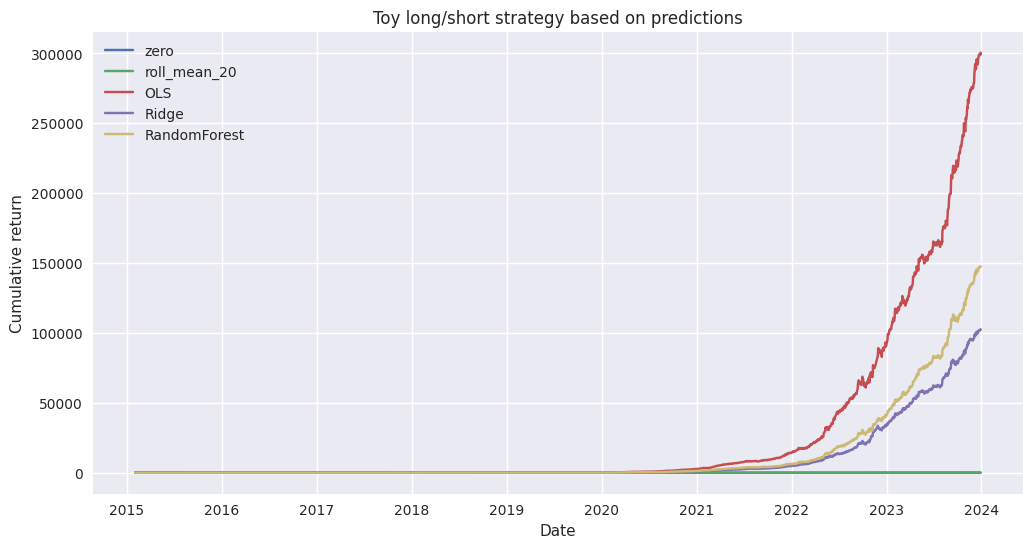

In [16]:
# TODO: plot your returns

plt.figure(figsize=(12, 6))
for name in strategy_returns.columns:
    cum_ret = (1 + strategy_returns[name].fillna(0)).cumprod() - 1
    plt.plot(strategy_returns.index, cum_ret, label=name)

plt.ylabel("Cumulative return")
plt.xlabel("Date")
plt.title("Toy long/short strategy based on predictions")
plt.legend()
plt.show()



## 10. Discussion questions

1. Why do we need naive baselines?
2. How does the evaluation strategy here (walk-forward evaluation) differ from the random training-test dataset splits used in convention ML?
3. *(Addon)* And, why does random splitting technique fail here?
4. Interpret the RMSE values and rolling RMSE plot results very briefly.
5. *(Addon)* Are there periods where model performance degrades noticeably? What might this indicate?
6. Why might Random Forest overfit?
7. *(Bonus)* Two models have similar RMSE, but one makes larger errors primarily during high-volatility periods. Why might this model be *less dangerous* in a portfolio context?